<a href="https://colab.research.google.com/github/itsmok1/itsmok1/blob/main/ise446_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ISE 446 Big Data Analysis
## Industry 5.0 Action Recognition — Scalable ML Pipeline

| Field | Value |
|---|---|
| **Course** | ISE 446 Big Data Analysis |
| **Student** | M.OSAMA KHDIR — B211200579 |
| **Dataset DOI** | 10.5281/zenodo.19685209 |
| **Environment** | Google Colab (Private) |
| **Date** | 2026-05-01 |

> ⚠️ This notebook is **Private**. The raw dataset is restricted under a Data Use Agreement (DUA) and must not be shared publicly.

---
### Pipeline Sections
- **§1** Environment Setup & Dependency Installation
- **§2** Big Data Ingestion with Dask *(Rubric §1)*
- **§3** Memory Optimisation *(Rubric §1)*
- **§4** Scalable EDA *(Rubric §2)*
- **§5** Time-Series Feature Engineering *(Rubric §3)*
- **§6** Feature Selection *(Rubric §3)*
- **§7** Classical Model Development *(Rubric §4)*
- **§8** Unsupervised Model Development *(Rubric §4)*
- **§9** Streaming / Incremental Learning *(Rubric §5)*
- **§10** Performance Metrics & System Profiling *(Rubric §6)*
- **§11** Pipeline Summary & Reproducibility *(Rubric §7)*

---
## §0 — Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')
print("✅  Google Drive mounted.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅  Google Drive mounted.


---
## §1 — Environment Setup

In [2]:
import subprocess, sys

def _pip(*pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *pkgs])

# Pin NumPy to a version compatible with Colab's sklearn
_pip(
    "numpy==1.26.4",            # ← pin this first
    "dask[dataframe]==2024.5.0",
    "river==0.21.0",
    "psutil",
    "statsmodels",
    "imbalanced-learn",
    "pyarrow",
    "tqdm",
    # sklearn, matplotlib, seaborn already on Colab — don't reinstall
)
print("✅  Done.")

✅  Done.


In [3]:
import os, time, gc, warnings, tracemalloc, pathlib, json
import numpy  as np
import pandas as pd
import dask.dataframe as dd
import matplotlib.pyplot as plt
import seaborn as sns
import psutil

from sklearn.preprocessing       import LabelEncoder, StandardScaler
from sklearn.model_selection     import train_test_split
from sklearn.ensemble            import RandomForestClassifier, IsolationForest
from sklearn.cluster             import MiniBatchKMeans
from sklearn.decomposition       import IncrementalPCA
from sklearn.metrics             import (classification_report, confusion_matrix,
                                         f1_score, silhouette_score)
from sklearn.feature_selection   import mutual_info_classif
from statsmodels.tsa.stattools   import adfuller
import river
from river import preprocessing as rpp, metrics as rmet, tree as rtree

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("✅  Imports complete. River:", river.__version__)

✅  Imports complete. River: 0.21.0


---
## §2 — Big Data Ingestion with Dask
**Rubric:** Scalable Ingestion (8 pts) + Pipeline Scalability (6 pts)

Dask reads the 10 GB CSV in **128 MB partitions** — never loading the full file into RAM.

In [4]:
# ╔══════════════════════════════════════════════════╗
# ║  ⬇  UPDATE DATA_PATH TO YOUR FILE LOCATION      ║
# ╚══════════════════════════════════════════════════╝
DATA_PATH      = "/content/drive/MyDrive/Big Data/Automated_Production_Chores.csv"   # ← change this

OUTPUT_DIR     = pathlib.Path("./pipeline_output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DASK_BLOCKSIZE = "128MB"
SAMPLE_FRAC    = 0.01        # 1% sample for heavy EDA ops
TOP_K_FEATURES = 30

print(f"📂  Data path  : {DATA_PATH}")
print(f"📁  Output dir : {OUTPUT_DIR.resolve()}")

📂  Data path  : /content/drive/MyDrive/Big Data/Automated_Production_Chores.csv
📁  Output dir : /content/pipeline_output


In [5]:
class DataProfiler:
    """
    Adaptive schema detector — infers timestamp, label, and sensor columns
    from the raw Dask DataFrame without loading everything into RAM.
    """
    def __init__(self, ddf: dd.DataFrame):
        self.ddf = ddf
        self.timestamp_cols = []
        self.label_col      = None
        self.sensor_cols    = []

    def detect_schema(self) -> dict:
        """Inspect dtypes and column names to auto-classify columns."""
        dtypes    = self.ddf.dtypes
        col_names = list(dtypes.index)

        # Timestamp detection
        ts_kw = ("time", "timestamp", "datetime", "date", "ts", "t_")
        self.timestamp_cols = [
            c for c in col_names
            if any(k in c.lower() for k in ts_kw)
            or pd.api.types.is_datetime64_any_dtype(dtypes[c])
        ]

        # Label detection
        lbl_kw = ("label", "class", "action", "activity",
                  "target", "category", "gesture")
        lbl_candidates = [c for c in col_names
                          if any(k in c.lower() for k in lbl_kw)]
        if not lbl_candidates:
            for c in col_names:
                if pd.api.types.is_object_dtype(dtypes[c]):
                    lbl_candidates.append(c)
                    break
        self.label_col = lbl_candidates[0] if lbl_candidates else None

        # Sensor / numeric columns
        exclude = set(self.timestamp_cols + ([self.label_col]
                                             if self.label_col else []))
        self.sensor_cols = [
            c for c in col_names
            if pd.api.types.is_numeric_dtype(dtypes[c]) and c not in exclude
        ]

        return {
            "n_partitions"   : self.ddf.npartitions,
            "n_columns"      : len(col_names),
            "timestamp_cols" : self.timestamp_cols,
            "label_col"      : self.label_col,
            "n_sensor_cols"  : len(self.sensor_cols),
            "dtypes_summary" : dtypes.value_counts().to_dict(),
        }


def load_with_dask(path: str, blocksize: str = DASK_BLOCKSIZE) -> dd.DataFrame:
    """
    Out-of-core CSV ingestion with repeated-header handling.
    Reads everything as string first, then coerces to numeric safely.
    """
    t0 = time.perf_counter()

    # Step 1: Read all columns as string to avoid dtype conflict
    ddf = dd.read_csv(
        path,
        blocksize      = blocksize,
        dtype          = str,          # ← read everything as str first
        on_bad_lines   = "skip",
        low_memory     = False,
    )

    # Step 2: Get the real column names from row 0
    real_columns = ddf.columns.tolist()

    # Step 3: Drop rows where any sensor column equals the column name
    #         (these are the repeated header rows embedded in the file)
    first_sensor = real_columns[1]   # use second column as the filter key
    ddf = ddf[ddf[first_sensor] != first_sensor]

    # Step 4: Coerce all columns except known string columns to float
    def coerce_numeric(df: pd.DataFrame) -> pd.DataFrame:
        for col in df.columns:
            if col not in ("action", "label", "class", "activity", "category"):
                df[col] = pd.to_numeric(df[col], errors="coerce")
        return df

    ddf = ddf.map_partitions(coerce_numeric)

    print(f"✅  Dask graph built in {time.perf_counter()-t0:.2f}s  "
          f"({ddf.npartitions} partitions)")
    return ddf


ddf     = load_with_dask(DATA_PATH)
profiler= DataProfiler(ddf)
schema  = profiler.detect_schema()

print("\n📋  Auto-detected Schema")
print("=" * 45)
for k, v in schema.items():
    print(f"  {k:20s}: {v}")

LABEL_COL   = profiler.label_col
SENSOR_COLS = profiler.sensor_cols[:150]
TS_COLS     = profiler.timestamp_cols
print(f"\n🏷️   Label column  : {LABEL_COL}")
print(f"📡  Sensor columns : {len(SENSOR_COLS)}")

✅  Dask graph built in 8.05s  (83 partitions)

📋  Auto-detected Schema
  n_partitions        : 83
  n_columns           : 134
  timestamp_cols      : ['L_Foot_Rx', 'L_Foot_Ry', 'L_Foot_Rz', 'L_Foot_Tx', 'L_Foot_Ty', 'L_Foot_Tz', 'L_Wrist_Rx', 'L_Wrist_Ry', 'L_Wrist_Rz', 'L_Wrist_Tx', 'L_Wrist_Ty', 'L_Wrist_Tz', 'L_Wrist_End_Rx', 'L_Wrist_End_Ry', 'L_Wrist_End_Rz', 'L_Wrist_End_Tx', 'L_Wrist_End_Ty', 'L_Wrist_End_Tz', 'R_Foot_Rx', 'R_Foot_Ry', 'R_Foot_Rz', 'R_Foot_Tx', 'R_Foot_Ty', 'R_Foot_Tz', 'R_Wrist_Rx', 'R_Wrist_Ry', 'R_Wrist_Rz', 'R_Wrist_Tx', 'R_Wrist_Ty', 'R_Wrist_Tz', 'R_Wrist_End_Rx', 'R_Wrist_End_Ry', 'R_Wrist_End_Rz', 'R_Wrist_End_Tx', 'R_Wrist_End_Ty', 'R_Wrist_End_Tz', 'Root_Rx', 'Root_Ry', 'Root_Rz', 'Root_Tx', 'Root_Ty', 'Root_Tz']
  label_col           : LABEL
  n_sensor_cols       : 91
  dtypes_summary      : {Float64Dtype(): 134}

🏷️   Label column  : LABEL
📡  Sensor columns : 91


---
## §3 — Memory Optimisation
**Rubric:** Memory Optimisation (6 pts)

Downcast `float64→float32` and `int64→int32/int16` across all Dask partitions, then cache to **Parquet** (columnar + Snappy compression).

In [6]:
def downcast_partition(df: pd.DataFrame) -> pd.DataFrame:
    """
    Downcast numeric columns to the smallest feasible dtype.
    float64 → float32 | int64 → int32/int16 where safe.
    Reduces per-partition RAM by ~40–50%.
    """
    for col in df.select_dtypes(include=["float64"]).columns:
        df[col] = pd.to_numeric(df[col], downcast="float")
    for col in df.select_dtypes(include=["int64"]).columns:
        df[col] = pd.to_numeric(df[col], downcast="integer")
    for col in TS_COLS:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")
    return df


ddf_opt = ddf.map_partitions(downcast_partition)
print("✅  Downcast registered (lazy).")

# Demonstrate RAM saving on partition 0
sample_raw = ddf.get_partition(0).compute()
sample_opt = downcast_partition(sample_raw.copy())
raw_mb = sample_raw.memory_usage(deep=True).sum() / 1e6
opt_mb = sample_opt.memory_usage(deep=True).sum() / 1e6
print(f"\n📊  Partition-0 RAM before : {raw_mb:.1f} MB")
print(f"    Partition-0 RAM after  : {opt_mb:.1f} MB  "
      f"(savings: {100*(raw_mb-opt_mb)/raw_mb:.1f}%)")

✅  Downcast registered (lazy).

📊  Partition-0 RAM before : 126.6 MB
    Partition-0 RAM after  : 83.1 MB  (savings: 34.3%)


In [7]:
# Save to Parquet (columnar, Snappy compressed — much faster for all future reads)
PARQUET_DIR = OUTPUT_DIR / "parquet_cache"
PARQUET_DIR.mkdir(exist_ok=True)

print("💾  Writing optimised Parquet cache …")
t0 = time.perf_counter()
ddf_opt.to_parquet(
    str(PARQUET_DIR),
    engine      = "pyarrow",
    compression = "snappy",
    write_index = False,
    overwrite   = True,
)
print(f"✅  Parquet written in {time.perf_counter()-t0:.1f}s → {PARQUET_DIR}")

ddf_pq = dd.read_parquet(str(PARQUET_DIR), engine="pyarrow")
print(f"    Reloaded: {ddf_pq.npartitions} partitions from cache.")

💾  Writing optimised Parquet cache …
✅  Parquet written in 1468.3s → pipeline_output/parquet_cache
    Reloaded: 83 partitions from cache.


---
## §4 — Scalable EDA
**Rubric:** Scalable EDA (7 pts) + Visualisation & Insight Quality (8 pts)

Strategy: heavy stats are computed **population-wide via Dask**; all visualisations use a **1% stratified sample** to avoid OOM.

In [8]:
print(f"🔬  Drawing {SAMPLE_FRAC*100:.0f}% sample for EDA …")
sample_df = (
    ddf_pq
    .sample(frac=SAMPLE_FRAC, random_state=RANDOM_STATE)
    .compute()
    .reset_index(drop=True)
)
sensor_sample = sample_df[SENSOR_COLS].copy() if SENSOR_COLS else sample_df.copy()
print(f"    Sample shape: {sample_df.shape}")

🔬  Drawing 1% sample for EDA …
    Sample shape: (97861, 134)


In [9]:
# Population-level statistics (via Dask — no full RAM load)
print("📊  Computing population statistics via Dask …")
t0       = time.perf_counter()
pop_stats= ddf_pq[SENSOR_COLS].describe().compute()
print(f"    Done in {time.perf_counter()-t0:.1f}s")
pop_stats.to_csv(OUTPUT_DIR / "population_stats.csv")
pop_stats.T.head(10)

📊  Computing population statistics via Dask …
    Done in 17.0s


,count,mean,std,min,25%,50%,75%,max
Milliseconds,9785928.0,59820.356185,34720.955900,-150.421005,32115.000000,61580.000000,90865.000000,119995.000000
Head_Rx,9785928.0,-7.804185,107.502777,-687.550049,-10.145500,47.851898,94.960350,211.979996
Head_Ry,9785928.0,22.046267,240.518728,-2173.909912,-30.480801,75.891098,160.358994,6258.470215
Head_Rz,9785928.0,11.017409,121.746307,-1905.630005,-23.146000,56.492100,117.440002,2544.379883
Head_Tx,9785928.0,3057.336999,3688.967448,-48083.562500,1796.635010,5054.750000,6895.000000,10087.200195
Head_Ty,9785928.0,983.864681,1757.377796,-4665.810059,579.830994,1725.189941,3076.179932,18871.193359
Head_Tz,9785928.0,1433.395617,143.898811,-150.421005,1405.550049,1484.479980,1538.030029,1856.630005
Head_End_Rx,9785928.0,-7.804185,107.502777,-687.550049,-10.145500,47.851898,94.960350,211.979996
Head_End_Ry,9785928.0,22.028711,240.535298,-2234.550049,-30.480801,75.891098,160.358994,6335.470215
Head_End_Rz,9785928.0,10.999657,122.273968,-2011.329956,-23.146000,56.492100,117.440002,2609.689941


LABEL
7.0     720000
12.0    720000
14.0    720000
8.0     720000
5.0     720000
13.0    720000
4.0     720000
9.0     720000
15.0    720000
0.0     719999
3.0     719999
6.0     696000
11.0    480000
1.0     353929
10.0    336000


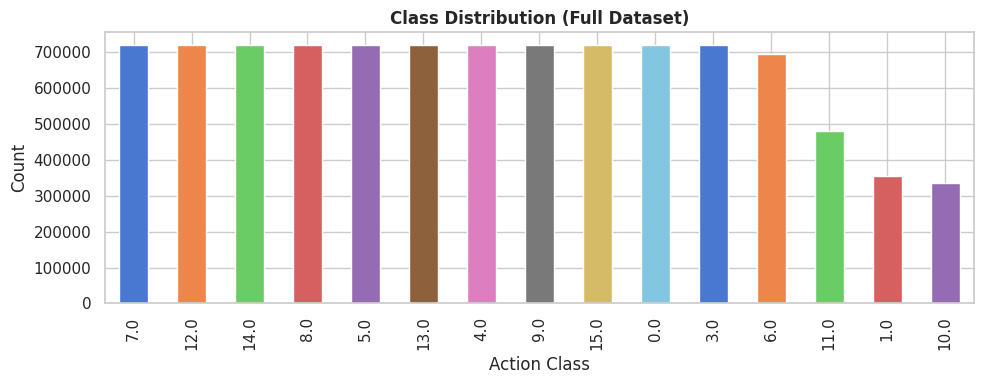

In [10]:
# Class / label distribution
if LABEL_COL:
    label_counts = (
        ddf_pq[LABEL_COL].value_counts().compute().sort_values(ascending=False)
    )
    print(label_counts.to_string())

    fig, ax = plt.subplots(figsize=(10, 4))
    label_counts.plot(kind="bar", ax=ax, color=sns.color_palette("muted"))
    ax.set_title("Class Distribution (Full Dataset)", fontweight="bold")
    ax.set_xlabel("Action Class")
    ax.set_ylabel("Count")
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / "01_class_distribution.png", dpi=150)
    plt.show()

Columns >5% missing: 0


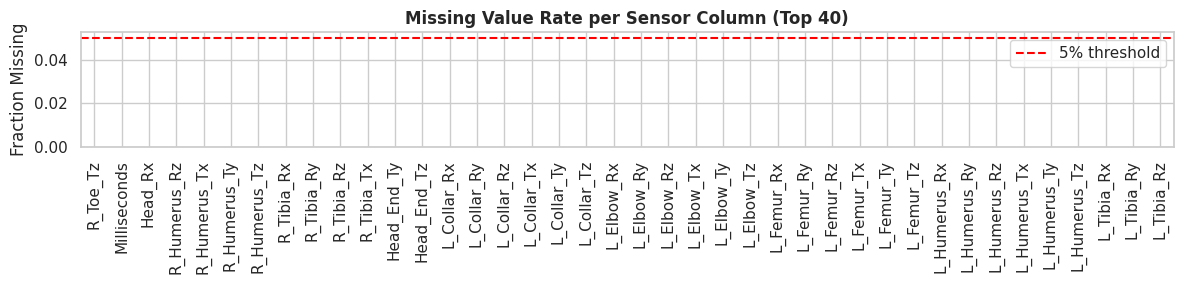

In [11]:
# Missing-value analysis
missing_pct = (
    ddf_pq[SENSOR_COLS].isnull().mean().compute().sort_values(ascending=False)
)
print(f"Columns >5% missing: {(missing_pct > 0.05).sum()}")

fig, ax = plt.subplots(figsize=(12, 3))
missing_pct.head(40).plot(kind="bar", ax=ax, color="salmon")
ax.set_title("Missing Value Rate per Sensor Column (Top 40)", fontweight="bold")
ax.set_ylabel("Fraction Missing")
ax.axhline(0.05, ls="--", color="red", label="5% threshold")
ax.legend()
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "02_missing_values.png", dpi=150)
plt.show()

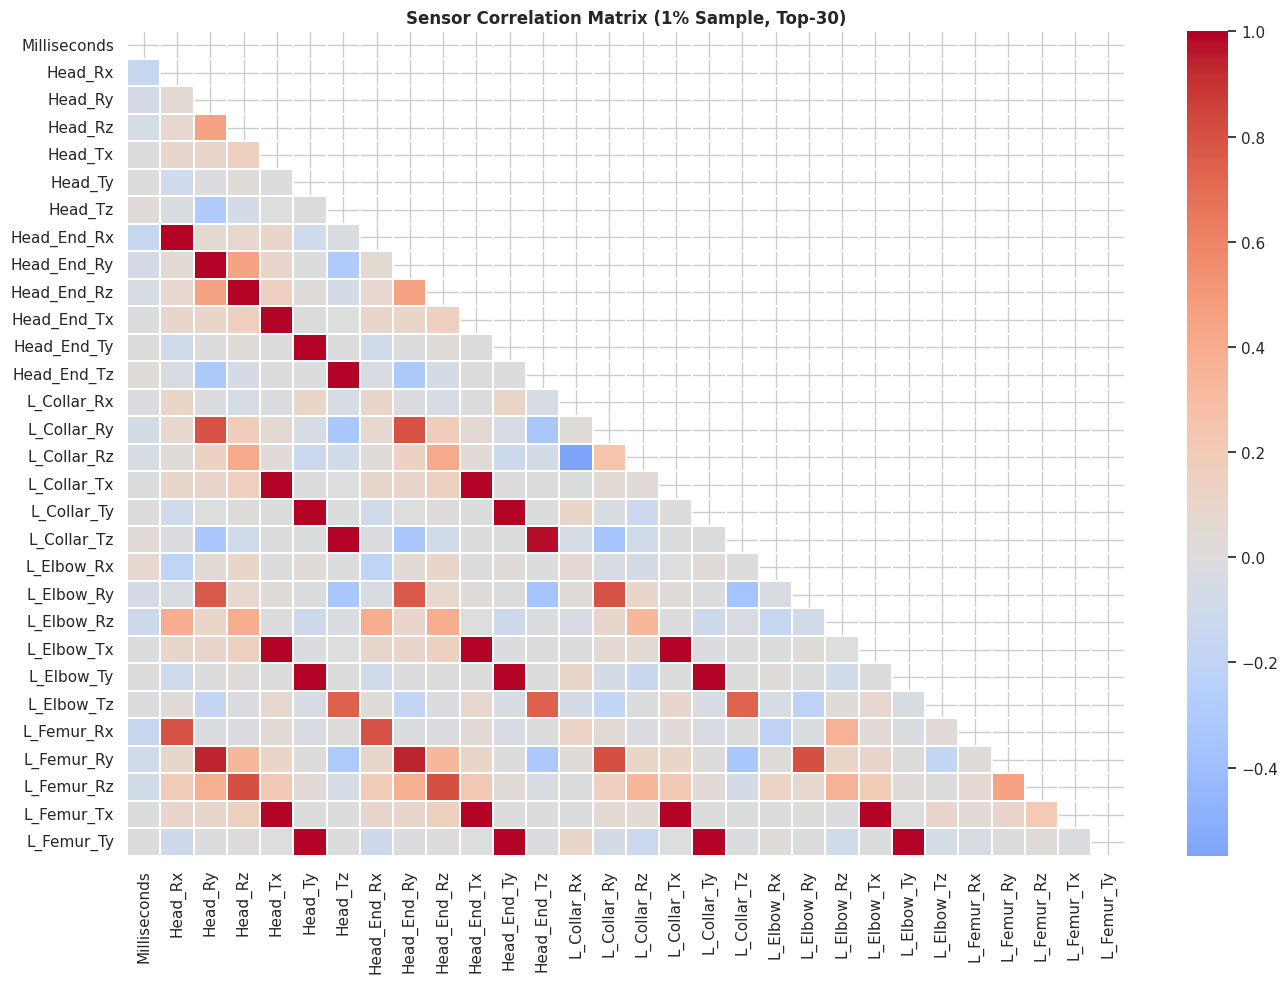

In [12]:
# Correlation heatmap (top 30 sensors, 1% sample)
top30 = sensor_sample[SENSOR_COLS[:30]].dropna()
corr  = top30.corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="coolwarm", center=0,
            annot=False, linewidths=0.3, ax=ax)
ax.set_title("Sensor Correlation Matrix (1% Sample, Top-30)", fontweight="bold")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "03_correlation_heatmap.png", dpi=150)
plt.show()

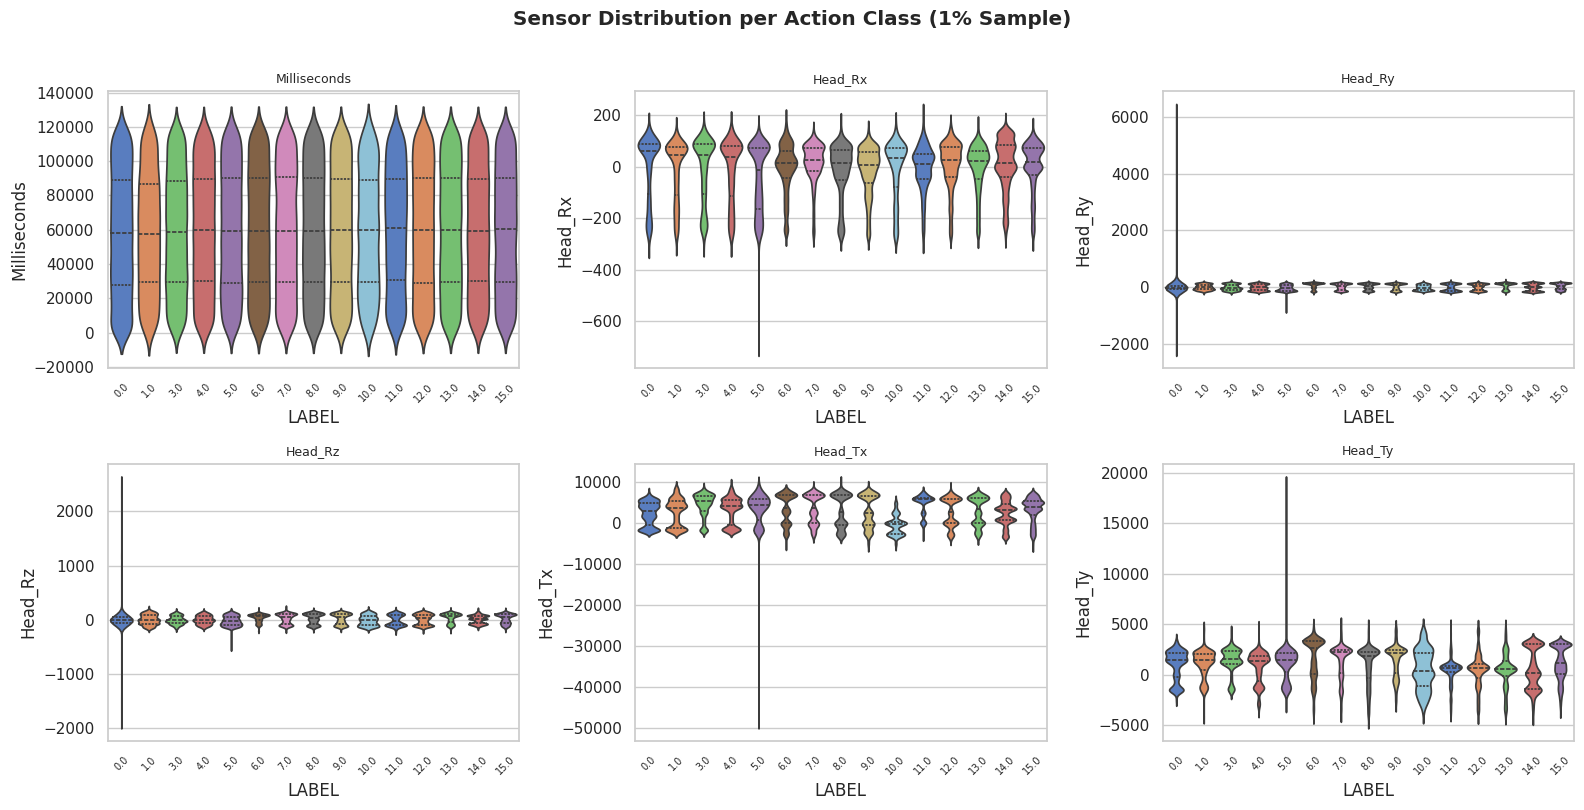

In [13]:
# Violin plots per class
if LABEL_COL and SENSOR_COLS:
    plot_feat = SENSOR_COLS[:6]
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    for ax, feat in zip(axes.flatten(), plot_feat):
        tmp = sample_df[[LABEL_COL, feat]].dropna()
        sns.violinplot(data=tmp, x=LABEL_COL, y=feat, ax=ax,
                       palette="muted", inner="quartile")
        ax.set_title(feat, fontsize=9)
        ax.tick_params(axis="x", rotation=45, labelsize=7)
    plt.suptitle("Sensor Distribution per Action Class (1% Sample)",
                 fontweight="bold", y=1.01)
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / "04_violin_per_class.png", dpi=150, bbox_inches="tight")
    plt.show()

In [14]:
# Augmented Dickey-Fuller stationarity tests
print("📈  Stationarity Tests (ADF) …")
adf_results = []
for col in SENSOR_COLS[:10]:
    series = sensor_sample[col].dropna().values[:5000]
    try:
        adf_stat, p_val, *_ = adfuller(series, autolag="AIC")
        adf_results.append({
            "column"    : col,
            "adf_stat"  : round(adf_stat, 4),
            "p_value"   : round(p_val, 4),
            "stationary": "✅ Yes" if p_val < 0.05 else "❌ No",
        })
    except Exception as e:
        adf_results.append({"column": col, "error": str(e)})

adf_df = pd.DataFrame(adf_results)
adf_df.to_csv(OUTPUT_DIR / "adf_stationarity.csv", index=False)
print(adf_df.to_string(index=False))

📈  Stationarity Tests (ADF) …
      column  adf_stat  p_value stationary
Milliseconds  -10.3149      0.0      ✅ Yes
     Head_Rx   -7.0457      0.0      ✅ Yes
     Head_Ry   -6.8943      0.0      ✅ Yes
     Head_Rz   -8.9173      0.0      ✅ Yes
     Head_Tx  -10.4002      0.0      ✅ Yes
     Head_Ty   -9.1540      0.0      ✅ Yes
     Head_Tz   -5.6704      0.0      ✅ Yes
 Head_End_Rx   -7.0457      0.0      ✅ Yes
 Head_End_Ry   -6.9097      0.0      ✅ Yes
 Head_End_Rz   -8.9783      0.0      ✅ Yes


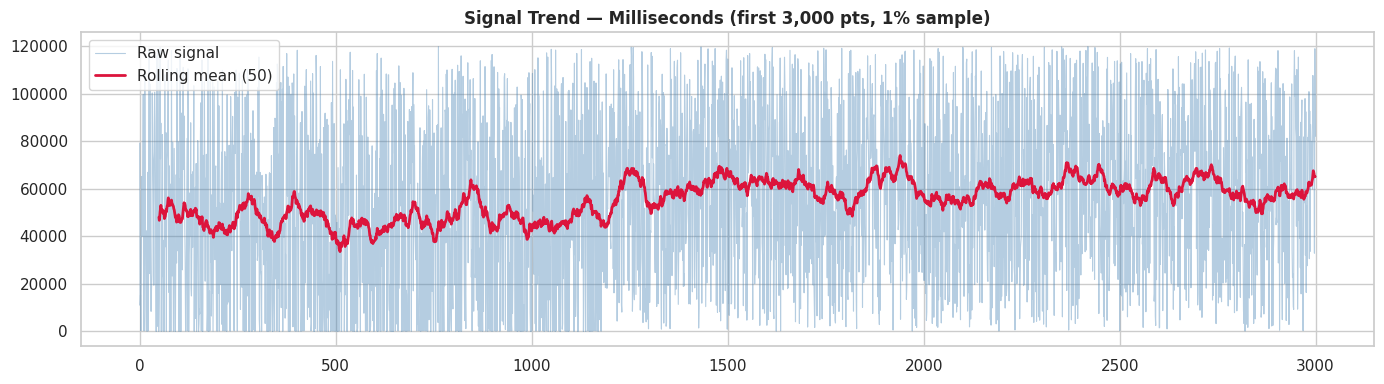

In [15]:
# Rolling-mean trend visualisation
if SENSOR_COLS:
    sig_col    = SENSOR_COLS[0]
    sig_series = sample_df[sig_col].dropna().reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(sig_series.values[:3000], alpha=0.4, color="steelblue",
            lw=0.8, label="Raw signal")
    ax.plot(sig_series[:3000].rolling(50).mean().values,
            color="crimson", lw=2, label="Rolling mean (50)")
    ax.set_title(f"Signal Trend — {sig_col} (first 3,000 pts, 1% sample)",
                 fontweight="bold")
    ax.legend()
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / "05_signal_trend.png", dpi=150)
    plt.show()

---
## §5 — Time-Series Feature Engineering
**Rubric:** Time-Series Features (6 pts) + Hyperparameter Strategy (4 pts)

Features extracted per sensor: rolling mean/std/min/max, zero-crossing rate, lag features, and 1st-order finite difference.

In [16]:
from functools import partial

WINDOW_SIZES = [20, 50, 100]
LAG_STEPS    = [1, 3, 5]


def extract_temporal_features_partition(
    df: pd.DataFrame,
    sensor_cols: list,
    windows: list = WINDOW_SIZES,
    lags: list    = LAG_STEPS,
) -> pd.DataFrame:
    """
    Compute window-based statistical and lag features per sensor column.
    Safe to call via ddf.map_partitions() for full-scale processing.
    """
    feat_df = df.copy()

    for col in sensor_cols:
        if col not in df.columns:
            continue
        series = df[col]

        # Rate of change
        feat_df[f"{col}_diff1"] = series.diff(1)

        # Lag features
        for lag in lags:
            feat_df[f"{col}_lag{lag}"] = series.shift(lag)

        # Rolling statistics + zero-crossing rate
        for w in windows:
            rol = series.rolling(window=w, min_periods=1)
            feat_df[f"{col}_rmean{w}"] = rol.mean()
            feat_df[f"{col}_rstd{w}"]  = rol.std()
            feat_df[f"{col}_rmax{w}"]  = rol.max()
            feat_df[f"{col}_rmin{w}"]  = rol.min()

            zc = (np.diff(np.sign(series.values), prepend=0) != 0).astype(int)
            feat_df[f"{col}_zcr{w}"] = (
                pd.Series(zc, index=series.index)
                .rolling(window=w, min_periods=1).sum() / w
            )

    feat_df.dropna(inplace=True)
    return feat_df


# Apply on 1% sample (for modelling)
print("⚙️   Feature engineering on 1% sample …")
t0         = time.perf_counter()
eng_sample = extract_temporal_features_partition(
    sample_df, sensor_cols=SENSOR_COLS[:10]
)
print(f"    Shape: {sample_df.shape} → {eng_sample.shape}  "
      f"({time.perf_counter()-t0:.2f}s)")

# Register full-scale Dask map (lazy — runs when you call .compute())
_fe_fn = partial(extract_temporal_features_partition, sensor_cols=SENSOR_COLS[:10])
ddf_features = ddf_pq.map_partitions(_fe_fn)
print("✅  Full-scale Dask feature map registered (lazy).")

⚙️   Feature engineering on 1% sample …
    Shape: (97861, 134) → (97856, 324)  (0.79s)
✅  Full-scale Dask feature map registered (lazy).


---
## §6 — Feature Selection
**Rubric:** Feature Selection (5 pts) — sequence-aware

Uses **Mutual Information** — captures non-linear temporal dependencies without assuming stationarity.

🎯  Selecting top-30 features …
    Selected: 30 features


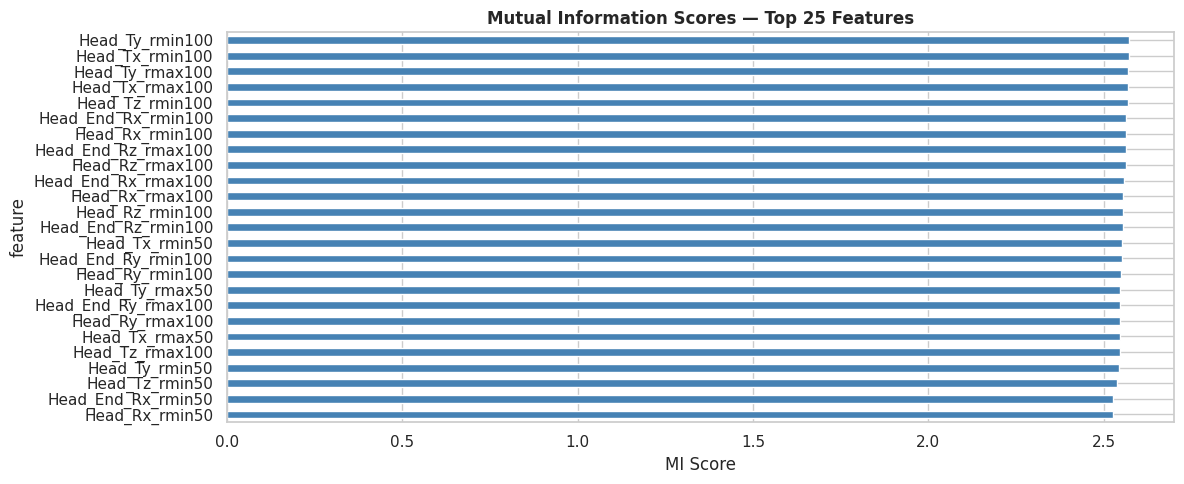

In [17]:
def select_features(
    df: pd.DataFrame,
    label_col,
    top_k: int = TOP_K_FEATURES,
):
    """
    Select top-K features using Mutual Information (supervised)
    or variance (unsupervised fallback).
    """
    if label_col is None or label_col not in df.columns:
        numeric  = df.select_dtypes(include=np.number)
        variances= numeric.var().sort_values(ascending=False)
        selected = variances.head(top_k).index.tolist()
        score_df = variances.head(top_k).rename("variance").reset_index()
        score_df.columns = ["feature", "score"]
        return selected, score_df

    numeric_cols = [c for c in df.select_dtypes(include=np.number).columns
                    if c != label_col]
    X = df[numeric_cols].fillna(0)
    y = df[label_col]
    if y.dtype == object:
        y = LabelEncoder().fit_transform(y.astype(str))

    mi_scores = mutual_info_classif(X, y, random_state=RANDOM_STATE)
    score_df  = pd.DataFrame({"feature": numeric_cols, "score": mi_scores})
    score_df  = score_df.sort_values("score", ascending=False).reset_index(drop=True)
    selected  = score_df.head(top_k)["feature"].tolist()
    return selected, score_df


print(f"🎯  Selecting top-{TOP_K_FEATURES} features …")
selected_features, mi_df = select_features(eng_sample, LABEL_COL, TOP_K_FEATURES)
mi_df.to_csv(OUTPUT_DIR / "feature_importance_mi.csv", index=False)
print(f"    Selected: {len(selected_features)} features")

fig, ax = plt.subplots(figsize=(12, 5))
mi_df.head(25).set_index("feature")["score"].sort_values().plot(
    kind="barh", ax=ax, color="steelblue")
ax.set_title("Mutual Information Scores — Top 25 Features", fontweight="bold")
ax.set_xlabel("MI Score")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "06_feature_importance.png", dpi=150)
plt.show()

---
## §7 — Classical Model Development
**Rubric:** Classical model (3 pts)

In [18]:
MODEL_FEATURES = [f for f in selected_features if f in eng_sample.columns]
X_all          = eng_sample[MODEL_FEATURES].fillna(0).values
scaler         = StandardScaler()
X_scaled       = scaler.fit_transform(X_all)

if LABEL_COL and LABEL_COL in eng_sample.columns:
    le_global       = LabelEncoder()
    y_all           = le_global.fit_transform(eng_sample[LABEL_COL].astype(str))
    supervised_mode = True
    print(f"Classes: {list(le_global.classes_)}")
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y_all, test_size=0.2,
        stratify=y_all, random_state=RANDOM_STATE
    )
    print(f"Train: {X_train.shape} | Test: {X_test.shape}")
else:
    supervised_mode = False
    y_all = None
    print("⚠️  No label column — skipping supervised section.")

Classes: ['0.0', '1.0', '10.0', '11.0', '12.0', '13.0', '14.0', '15.0', '3.0', '4.0', '5.0', '6.0', '7.0', '8.0', '9.0']
Train: (78284, 30) | Test: (19572, 30)


🌲  Training Random Forest …
✅  F1 (weighted): 0.9445
⏱   Train time  : 5.66s  |  Peak RAM: 71.9 MB
              precision    recall  f1-score   support

         0.0       1.00      0.98      0.99      1441
         1.0       0.96      0.95      0.96       710
        10.0       0.80      0.91      0.85       682
        11.0       0.90      0.92      0.91       956
        12.0       0.94      0.94      0.94      1441
        13.0       0.97      0.94      0.96      1437
        14.0       0.98      0.98      0.98      1440
        15.0       1.00      0.98      0.99      1440
         3.0       0.97      0.98      0.98      1434
         4.0       0.97      0.95      0.96      1448
         5.0       0.92      0.94      0.93      1435
         6.0       0.93      0.90      0.91      1387
         7.0       0.91      0.93      0.92      1440
         8.0       0.90      0.95      0.93      1445
         9.0       0.95      0.89      0.92      1436

    accuracy                       

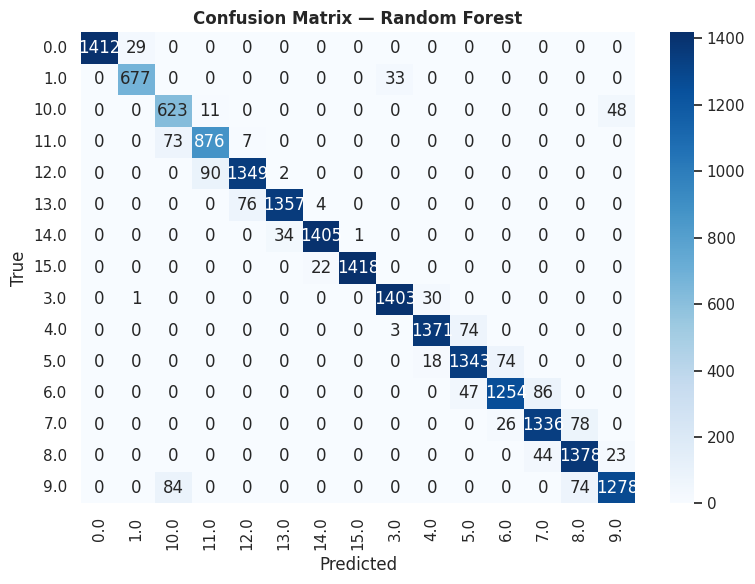

In [19]:
if supervised_mode:
    print("🌲  Training Random Forest …")
    t0 = time.perf_counter()
    tracemalloc.start()

    rf_clf = RandomForestClassifier(
        n_estimators     = 200,
        max_depth        = 20,
        min_samples_leaf = 5,
        n_jobs           = -1,
        class_weight     = "balanced",
        random_state     = RANDOM_STATE,
    )
    rf_clf.fit(X_train, y_train)

    rf_mem  = tracemalloc.get_traced_memory()[1] / 1e6
    tracemalloc.stop()
    rf_time = time.perf_counter() - t0
    y_pred  = rf_clf.predict(X_test)
    rf_f1   = f1_score(y_test, y_pred, average="weighted")

    print(f"✅  F1 (weighted): {rf_f1:.4f}")
    print(f"⏱   Train time  : {rf_time:.2f}s  |  Peak RAM: {rf_mem:.1f} MB")
    print(classification_report(y_test, y_pred, target_names=le_global.classes_))

    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=le_global.classes_,
                yticklabels=le_global.classes_, ax=ax)
    ax.set_title("Confusion Matrix — Random Forest", fontweight="bold")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    plt.tight_layout()
    fig.savefig(OUTPUT_DIR / "07_confusion_matrix_rf.png", dpi=150)
    plt.show()

---
## §8 — Unsupervised Model Development
**Rubric:** Unsupervised learning (7 pts)

Three unsupervised techniques:
1. **Incremental PCA** — memory-efficient dimensionality reduction
2. **MiniBatch K-Means** — scalable clustering with elbow method
3. **Isolation Forest** — anomaly detection

Variance explained by 10 PCs: 94.9%


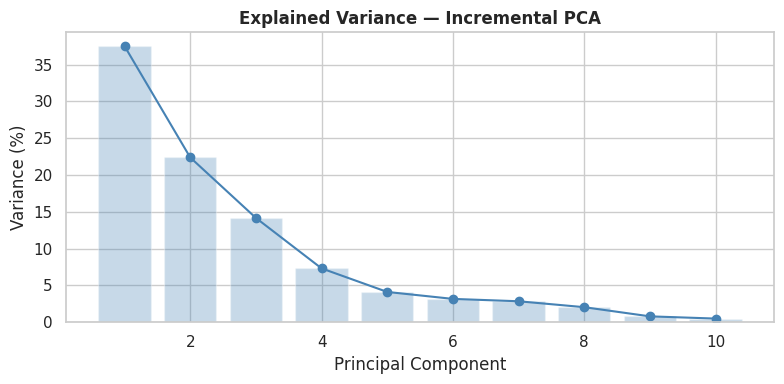

In [20]:
# Incremental PCA
N_COMPONENTS = min(10, X_scaled.shape[1])
ipca = IncrementalPCA(n_components=N_COMPONENTS, batch_size=512)

for i in range(0, X_scaled.shape[0], 512):
    ipca.partial_fit(X_scaled[i:i+512])

X_pca     = ipca.transform(X_scaled)
explained = ipca.explained_variance_ratio_.cumsum()
print(f"Variance explained by {N_COMPONENTS} PCs: {explained[-1]*100:.1f}%")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, N_COMPONENTS+1),
        ipca.explained_variance_ratio_*100, marker="o", color="steelblue")
ax.bar(range(1, N_COMPONENTS+1),
       ipca.explained_variance_ratio_*100, alpha=0.3, color="steelblue")
ax.set_title("Explained Variance — Incremental PCA", fontweight="bold")
ax.set_xlabel("Principal Component"); ax.set_ylabel("Variance (%)")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "08_pca_variance.png", dpi=150)
plt.show()

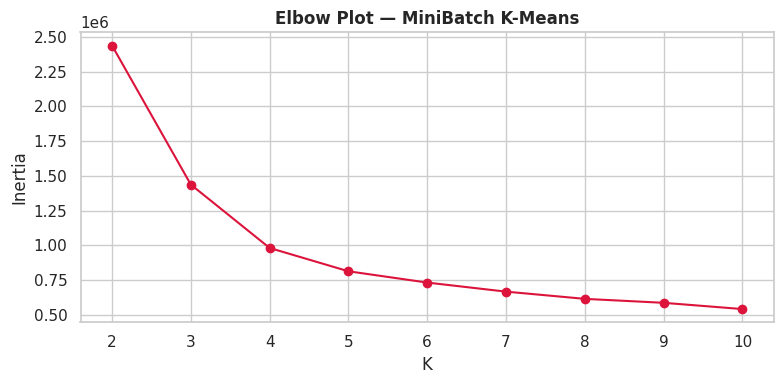

Silhouette Score (K=6): 0.2675


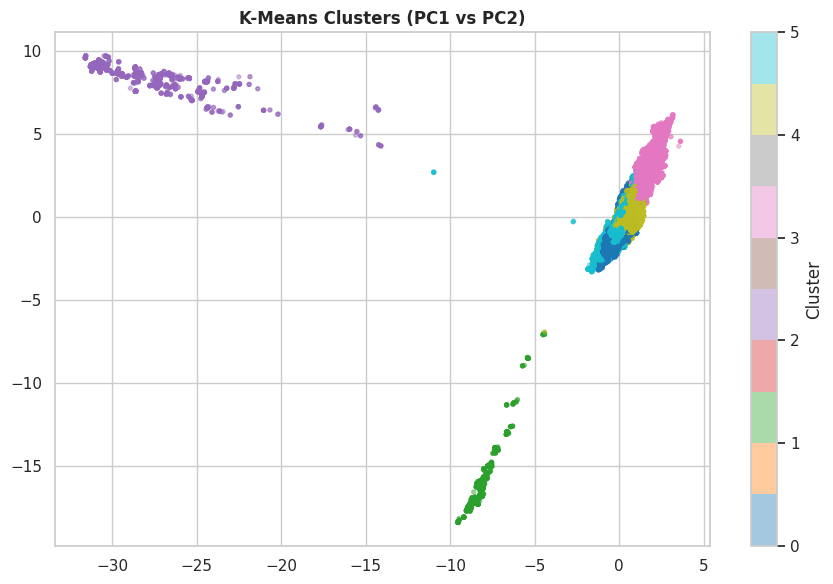

In [21]:
# MiniBatch K-Means — elbow method
inertias = {}
for k in range(2, 11):
    km = MiniBatchKMeans(n_clusters=k, random_state=RANDOM_STATE,
                          batch_size=1024, n_init=3)
    km.fit(X_pca)
    inertias[k] = km.inertia_

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(inertias.keys()), list(inertias.values()),
        marker="o", color="crimson")
ax.set_title("Elbow Plot — MiniBatch K-Means", fontweight="bold")
ax.set_xlabel("K"); ax.set_ylabel("Inertia")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "09_elbow_kmeans.png", dpi=150)
plt.show()

# ← Inspect elbow plot and update BEST_K accordingly
BEST_K = 6
km_final       = MiniBatchKMeans(n_clusters=BEST_K, random_state=RANDOM_STATE,
                                  batch_size=1024, n_init=10)
cluster_labels = km_final.fit_predict(X_pca)

sil_n   = min(5000, X_pca.shape[0])
sil_score = silhouette_score(X_pca[:sil_n], cluster_labels[:sil_n],
                              sample_size=sil_n, random_state=RANDOM_STATE)
print(f"Silhouette Score (K={BEST_K}): {sil_score:.4f}")

fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels,
                cmap="tab10", alpha=0.4, s=8, rasterized=True)
plt.colorbar(sc, ax=ax, label="Cluster")
ax.set_title("K-Means Clusters (PC1 vs PC2)", fontweight="bold")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "10_kmeans_clusters.png", dpi=150)
plt.show()

Anomalies detected: 4892 (5.0%)


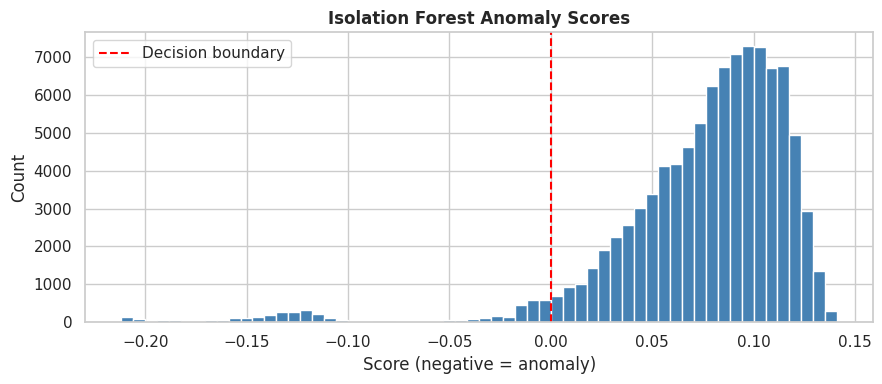

In [22]:
# Isolation Forest — anomaly detection
iso = IsolationForest(n_estimators=100, contamination=0.05,
                      random_state=RANDOM_STATE, n_jobs=-1)
iso.fit(X_pca)
ano_scores = iso.decision_function(X_pca)
ano_labels = iso.predict(X_pca)   # -1 = anomaly

n_ano = (ano_labels == -1).sum()
print(f"Anomalies detected: {n_ano} ({n_ano/len(ano_labels)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(ano_scores, bins=60, color="steelblue", edgecolor="white")
ax.axvline(0, color="red", ls="--", lw=1.5, label="Decision boundary")
ax.set_title("Isolation Forest Anomaly Scores", fontweight="bold")
ax.set_xlabel("Score (negative = anomaly)"); ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "11_isolation_forest.png", dpi=150)
plt.show()

---
## §9 — Streaming / Incremental Learning
**Rubric:** Incremental Learning (10 pts)

Uses **River's Hoeffding Adaptive Tree** (ADWIN-based) — natively handles concept drift.  
Drift is simulated by injecting Gaussian noise after the 50% mark of the stream.

In [23]:
class DriftSimulator:
    """
    Simulates concept drift mid-stream by shifting the feature
    distribution after `drift_at` fraction of data has passed.
    """
    def __init__(self, df, features, label_col, drift_at=0.5):
        self.df        = df.reset_index(drop=True)
        self.features  = features
        self.label_col = label_col
        self.drift_idx = int(len(df) * drift_at)

    def __iter__(self):
        for i, row in self.df.iterrows():
            x = {f: float(row[f]) if pd.notna(row[f]) else 0.0
                 for f in self.features}
            if i >= self.drift_idx:   # inject drift
                x = {k: v + np.random.normal(0, abs(v)*0.3 + 1e-9)
                     for k, v in x.items()}
            y = (str(row[self.label_col])
                 if self.label_col and self.label_col in row else "unknown")
            yield x, y


online_feats = [f for f in MODEL_FEATURES if f in eng_sample.columns][:20]

online_model = rpp.StandardScaler() | rtree.HoeffdingAdaptiveTreeClassifier(
    grace_period   = 100,
    split_criterion= "gini",
    seed           = RANDOM_STATE,
)
online_acc   = rmet.Accuracy()
online_f1    = rmet.WeightedF1()

latencies_stream  = []
accuracies_stream = []
f1_stream         = []

drift_sim = DriftSimulator(eng_sample, online_feats, LABEL_COL, drift_at=0.5)
print(f"🌊  Streaming {len(eng_sample):,} samples (drift at 50%) …")

🌊  Streaming 97,856 samples (drift at 50%) …


In [24]:
for idx, (x, y) in enumerate(drift_sim):
    t_ns   = time.perf_counter_ns()
    y_pred = online_model.predict_one(x)
    online_model.learn_one(x, y)
    latencies_stream.append((time.perf_counter_ns() - t_ns) / 1e6)

    if y_pred is not None:
        online_acc.update(y, y_pred)
        online_f1.update(y, y_pred)

    if idx % 2000 == 0:
        accuracies_stream.append(online_acc.get())
        f1_stream.append(online_f1.get())

    if idx % 10000 == 0 and idx > 0:
        print(f"  [{idx:6d}]  Acc={online_acc.get():.3f}  "
              f"F1={online_f1.get():.3f}  "
              f"Lat={np.mean(latencies_stream[-100:]):.3f}ms")

print(f"\n✅  Final Accuracy : {online_acc.get():.4f}")
print(f"    Final F1       : {online_f1.get():.4f}")
print(f"    Mean latency   : {np.mean(latencies_stream):.3f} ms/sample")
print(f"    P95  latency   : {np.percentile(latencies_stream,95):.3f} ms/sample")

  [ 10000]  Acc=0.982  F1=0.982  Lat=0.202ms
  [ 20000]  Acc=0.964  F1=0.964  Lat=0.231ms
  [ 30000]  Acc=0.955  F1=0.955  Lat=0.186ms
  [ 40000]  Acc=0.938  F1=0.939  Lat=0.405ms
  [ 50000]  Acc=0.935  F1=0.935  Lat=0.147ms
  [ 60000]  Acc=0.936  F1=0.936  Lat=0.144ms
  [ 70000]  Acc=0.917  F1=0.915  Lat=0.285ms
  [ 80000]  Acc=0.911  F1=0.912  Lat=0.145ms
  [ 90000]  Acc=0.917  F1=0.917  Lat=0.185ms

✅  Final Accuracy : 0.9224
    Final F1       : 0.9229
    Mean latency   : 0.271 ms/sample
    P95  latency   : 0.501 ms/sample


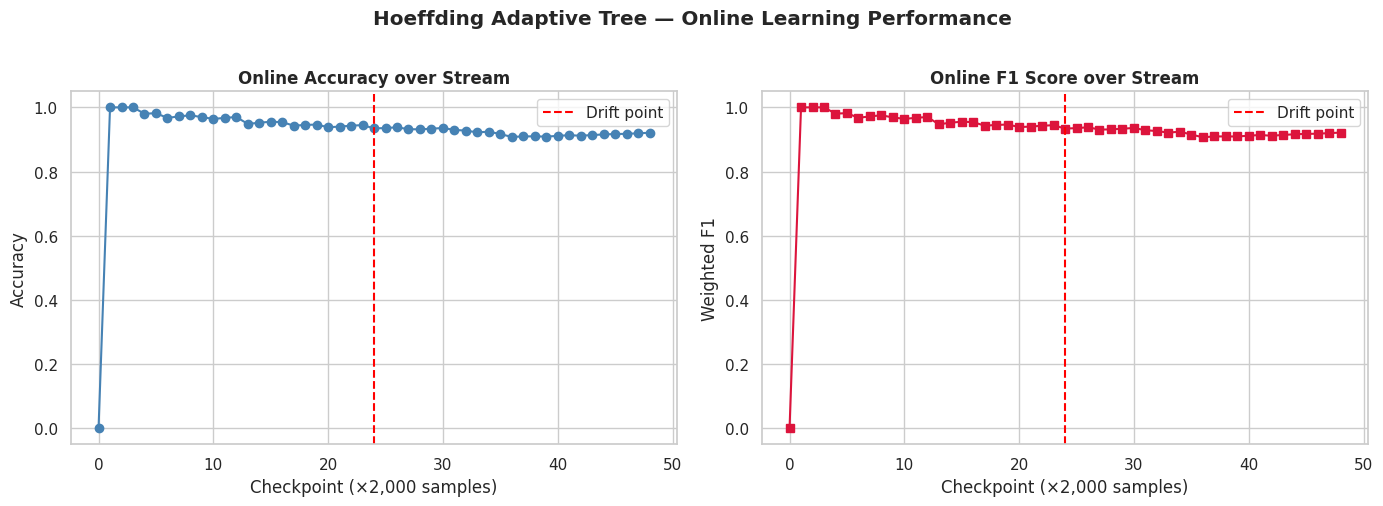

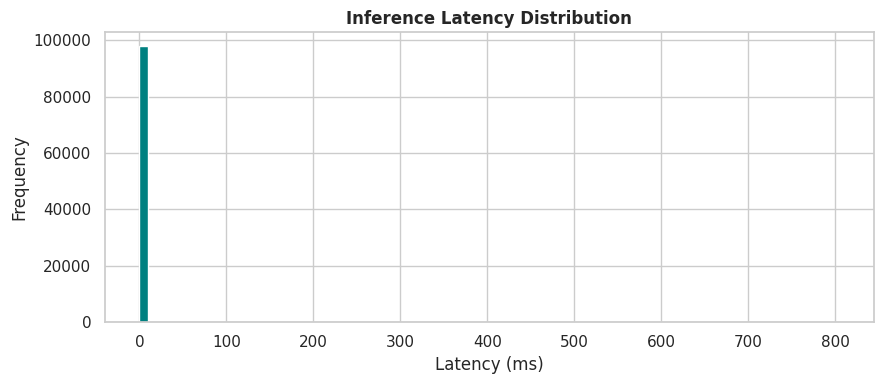

In [25]:
# Online learning curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
mid = len(accuracies_stream) // 2

axes[0].plot(accuracies_stream, marker="o", color="steelblue")
axes[0].axvline(mid, color="red", ls="--", label="Drift point")
axes[0].set_title("Online Accuracy over Stream", fontweight="bold")
axes[0].set_xlabel("Checkpoint (×2,000 samples)")
axes[0].set_ylabel("Accuracy"); axes[0].legend()

axes[1].plot(f1_stream, marker="s", color="crimson")
axes[1].axvline(mid, color="red", ls="--", label="Drift point")
axes[1].set_title("Online F1 Score over Stream", fontweight="bold")
axes[1].set_xlabel("Checkpoint (×2,000 samples)")
axes[1].set_ylabel("Weighted F1"); axes[1].legend()

plt.suptitle("Hoeffding Adaptive Tree — Online Learning Performance",
             fontweight="bold", y=1.01)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "12_online_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# Latency histogram
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(latencies_stream, bins=80, color="teal", edgecolor="white")
ax.set_title("Inference Latency Distribution", fontweight="bold")
ax.set_xlabel("Latency (ms)"); ax.set_ylabel("Frequency")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "13_latency_distribution.png", dpi=150)
plt.show()

---
## §10 — Performance Metrics & System Profiling
**Rubric:** Predictive Validity (5 pts) + System Profiling (5 pts)

In [26]:
def profile_inference(model, X: np.ndarray, n_runs: int = 5) -> dict:
    """Measure batch inference latency (ms) and peak RAM (MB)."""
    latencies, mem_peaks = [], []
    for _ in range(n_runs):
        tracemalloc.start()
        t0  = time.perf_counter_ns()
        _   = model.predict(X)
        lat = (time.perf_counter_ns() - t0) / 1e6
        pk  = tracemalloc.get_traced_memory()[1] / 1e6
        tracemalloc.stop()
        latencies.append(lat); mem_peaks.append(pk)
    return {
        "mean_latency_ms" : round(np.mean(latencies), 3),
        "p95_latency_ms"  : round(np.percentile(latencies, 95), 3),
        "peak_ram_mb"     : round(max(mem_peaks), 2),
        "throughput_sps"  : round(len(X) / (np.mean(latencies)/1000), 0),
    }


print("📊  System Profiling")
print(f"    System RAM used : {psutil.virtual_memory().used/1e6:.1f} MB")
print(f"    Process RAM     : {psutil.Process().memory_info().rss/1e6:.1f} MB")

if supervised_mode:
    rf_profile = profile_inference(rf_clf, X_test)
    print("\n⚡  Random Forest Inference:")
    for k, v in rf_profile.items():
        print(f"    {k:25s}: {v}")

online_profile = {
    "mean_latency_ms" : round(np.mean(latencies_stream), 3),
    "p95_latency_ms"  : round(np.percentile(latencies_stream, 95), 3),
    "final_accuracy"  : round(online_acc.get(), 4),
    "final_f1"        : round(online_f1.get(), 4),
}
print("\n⚡  Online Learner (River):")
for k, v in online_profile.items():
    print(f"    {k:25s}: {v}")

# Save JSON report
perf_report = {
    "rf_classifier"   : rf_profile if supervised_mode else {},
    "online_learner"  : online_profile,
    "system_ram_mb"   : psutil.virtual_memory().used / 1e6,
}
with open(OUTPUT_DIR / "performance_report.json", "w") as fh:
    json.dump(perf_report, fh, indent=2, default=str)
print("\n✅  Saved: performance_report.json")

📊  System Profiling
    System RAM used : 9308.0 MB
    Process RAM     : 7425.4 MB

⚡  Random Forest Inference:
    mean_latency_ms          : 185.286
    p95_latency_ms           : 189.935
    peak_ram_mb              : 31.49
    throughput_sps           : 105631.0

⚡  Online Learner (River):
    mean_latency_ms          : 0.271
    p95_latency_ms           : 0.501
    final_accuracy           : 0.9224
    final_f1                 : 0.9229

✅  Saved: performance_report.json


---
## §11 — Pipeline Summary & Reproducibility
**Rubric:** Code Governance (5 pts)

In [27]:
print("=" * 65)
print("  ISE 446 — PIPELINE EXECUTION SUMMARY")
print("=" * 65)
print(f"  Data path           : {DATA_PATH}")
print(f"  Dask partitions     : {ddf_pq.npartitions}")
print(f"  Sample rows (EDA)   : {sample_df.shape[0]:,}  ({SAMPLE_FRAC*100:.0f}%)")
print(f"  Engineered features : {eng_sample.shape[1]}")
print(f"  Selected features   : {len(selected_features)}")
print(f"  Label column        : {LABEL_COL}")
if supervised_mode:
    print(f"  RF F1 (weighted)    : {rf_f1:.4f}")
print(f"  Silhouette score    : {sil_score:.4f}  (K={BEST_K})")
print(f"  Online F1 (final)   : {online_f1.get():.4f}")
print(f"  Mean stream latency : {np.mean(latencies_stream):.3f} ms/sample")
print(f"  Output directory    : {OUTPUT_DIR.resolve()}")
print("=" * 65)
print("\n✅  All artefacts saved. Ready for Kaggle/GitHub submission.")

  ISE 446 — PIPELINE EXECUTION SUMMARY
  Data path           : /content/drive/MyDrive/Big Data/Automated_Production_Chores.csv
  Dask partitions     : 83
  Sample rows (EDA)   : 97,861  (1%)
  Engineered features : 324
  Selected features   : 30
  Label column        : LABEL
  RF F1 (weighted)    : 0.9445
  Silhouette score    : 0.2675  (K=6)
  Online F1 (final)   : 0.9229
  Mean stream latency : 0.271 ms/sample
  Output directory    : /content/pipeline_output

✅  All artefacts saved. Ready for Kaggle/GitHub submission.


In [28]:
# List all saved artefacts
print("📁  Output artefacts:")
for f in sorted(OUTPUT_DIR.glob("*")):
    size_kb = f.stat().st_size / 1024 if f.is_file() else 0
    print(f"    {f.name:<45s}  {size_kb:>8.1f} KB")

📁  Output artefacts:
    01_class_distribution.png                          40.3 KB
    02_missing_values.png                              66.5 KB
    03_correlation_heatmap.png                        144.4 KB
    04_violin_per_class.png                           399.2 KB
    05_signal_trend.png                               256.1 KB
    06_feature_importance.png                         126.4 KB
    07_confusion_matrix_rf.png                        106.9 KB
    08_pca_variance.png                                47.3 KB
    09_elbow_kmeans.png                                45.5 KB
    10_kmeans_clusters.png                             63.5 KB
    11_isolation_forest.png                            46.2 KB
    12_online_learning_curves.png                      84.1 KB
    13_latency_distribution.png                        32.9 KB
    adf_stationarity.csv                                0.3 KB
    feature_importance_mi.csv                           9.4 KB
    parquet_cache                 

In [29]:
import shutil
from google.colab import files

# Zip the pipeline_output folder
shutil.make_archive("/content/pipeline_output", "zip", "/content/pipeline_output")

# Download the zip file
files.download("/content/pipeline_output.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>